<a href="https://colab.research.google.com/github/ayushmahar38/bank-marketing-campaign-analysis/blob/main/Advance_Bank_Term_Deposit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data with standard comma separator
df = pd.read_csv('/content/data.csv')

# Display first few rows
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

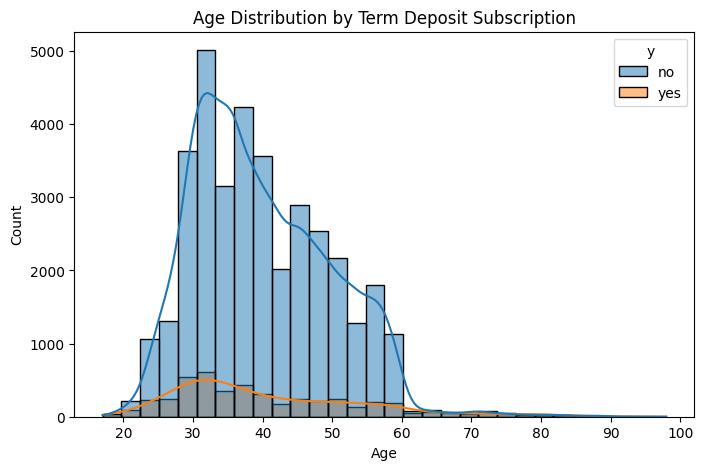

In [41]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='y', kde=True, bins=30)
plt.title('Age Distribution by Term Deposit Subscription')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

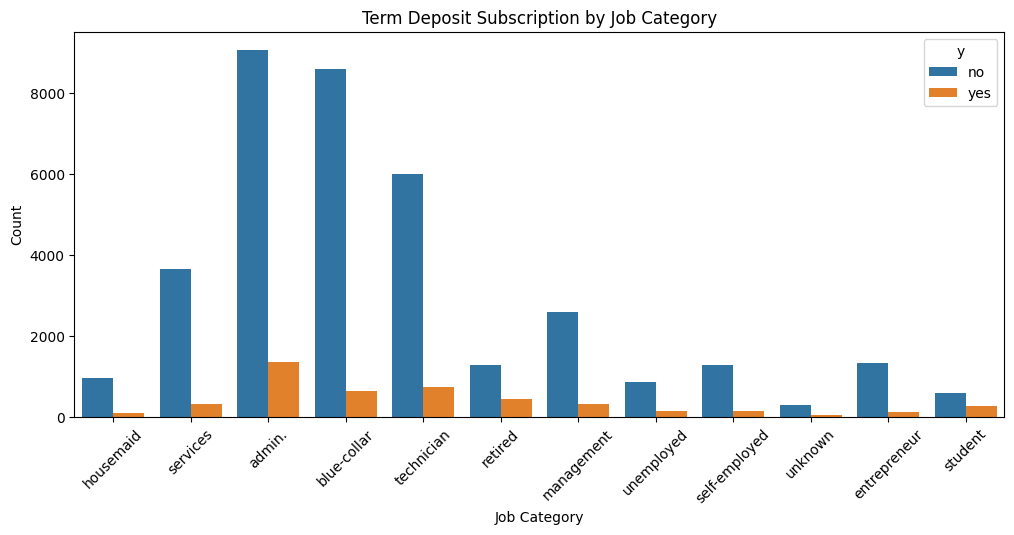

In [42]:
# Job distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y')
plt.xticks(rotation=45)
plt.title('Term Deposit Subscription by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.show()

## Balance & Deposit Trends

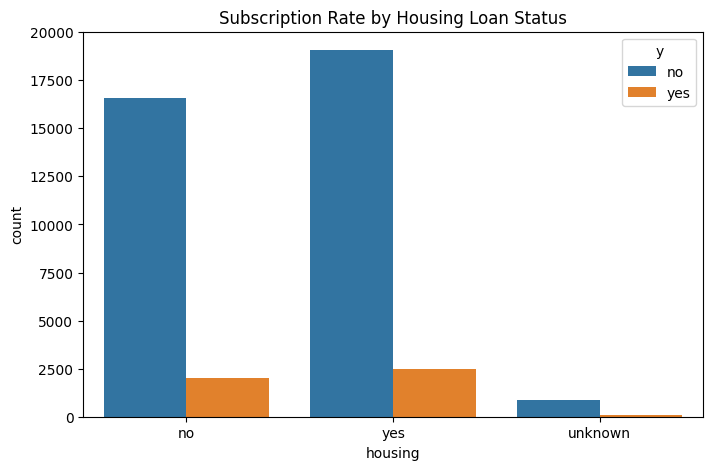

In [43]:
# Balance distribution by subscription
plt.figure(figsize=(8, 5))
if 'balance' in df.columns:
    sns.boxplot(data=df, x='y', y='balance', showfliers=False)
    plt.title('Account Balance by Term Deposit Subscription')
    plt.xlabel('Subscribed to Term Deposit (y)')
    plt.ylabel('Balance')
else:
    sns.countplot(data=df, x='housing', hue='y')
    plt.title('Subscription Rate by Housing Loan Status')
plt.show()

## Campaign Effectiveness

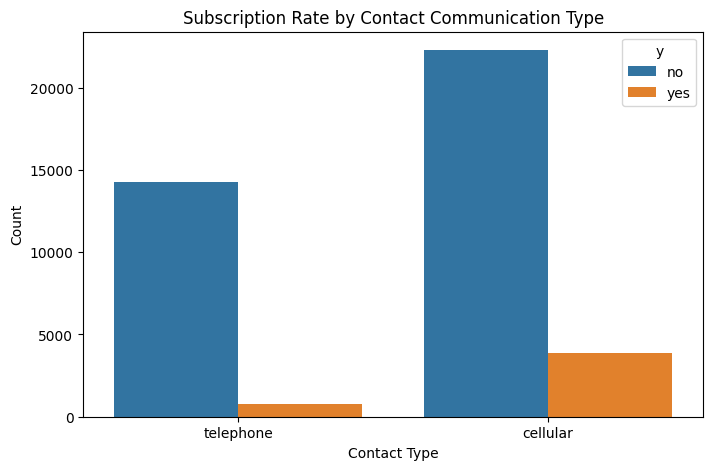

In [44]:
# Contact method analysis
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contact', hue='y')
plt.title('Subscription Rate by Contact Communication Type')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.show()

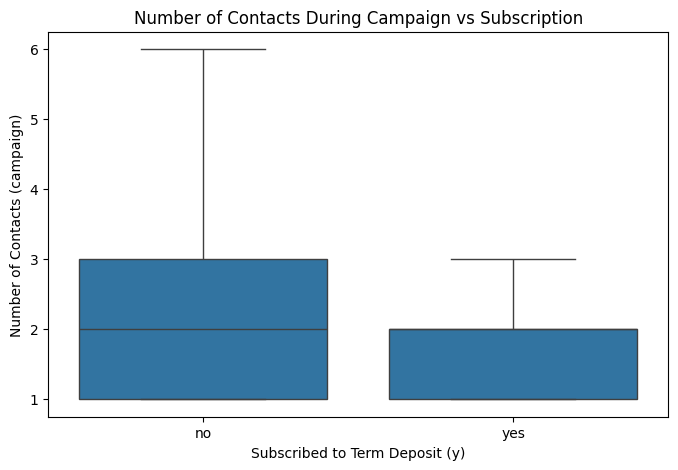

In [45]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='campaign', showfliers=False)
plt.title('Number of Contacts During Campaign vs Subscription')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Number of Contacts (campaign)')
plt.show()

## Correlation Heatmap

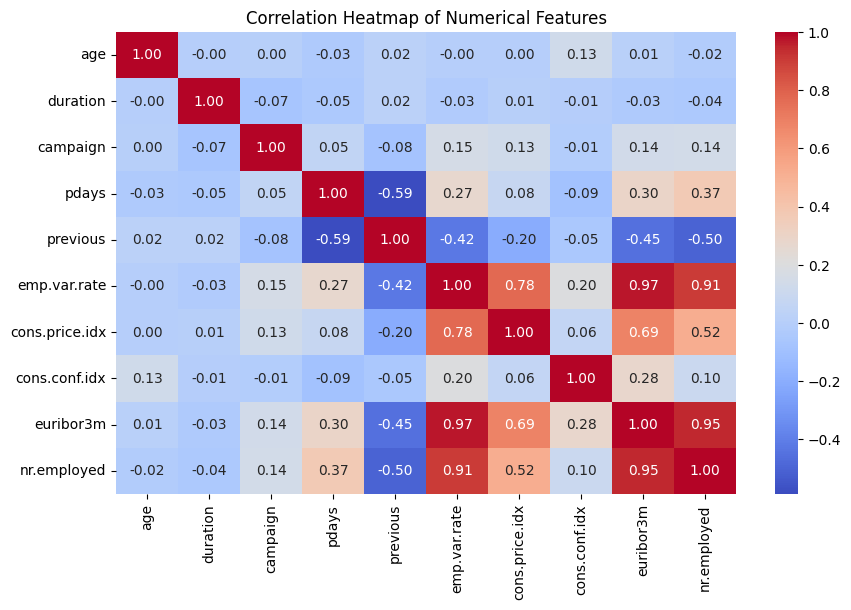

In [46]:
# Correlation of numerical variables
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Predictive Modeling (Logistic Regression)

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target ('y' column)
X = df.drop(columns=['y'])
y = df['y'].map({'no': 0, 'yes': 1})

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9104151493080845

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


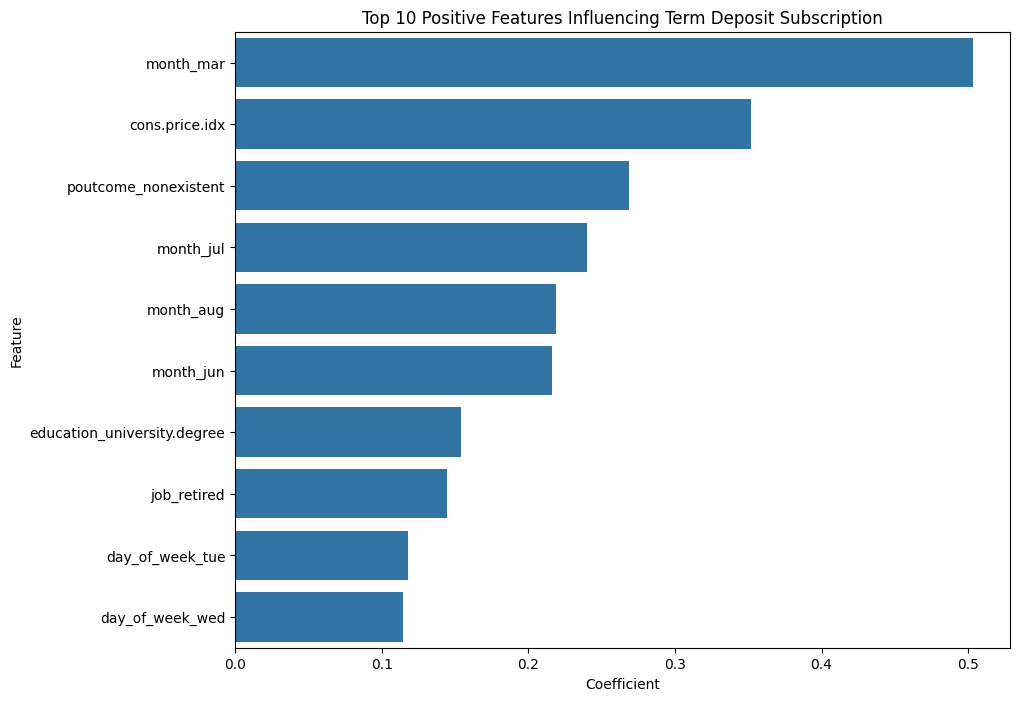

In [48]:
# Feature importance visualization
import numpy as np

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Positive Features Influencing Term Deposit Subscription')
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.